In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, 
                            confusion_matrix, classification_report,
                            precision_score, accuracy_score)
import time
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [45]:
X_train = np.load("../data/processed/X_train.npy")   
X_val = np.load("../data/processed/X_val.npy")          
X_test = np.load("../data/processed/X_test.npy")        

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")

In [46]:
print("="*60)
print("ДАННЫЕ ЗАГРУЖЕНЫ")
print("="*60)
print(f"Train: {X_train.shape}, Target: {y_train.shape}")
print(f"Val:   {X_val.shape}, Target: {y_val.shape}")
print(f"Test:  {X_test.shape}, Target: {y_test.shape}")
print(f"\nClass distribution:")
print(f"Train - Legit: {np.sum(y_train==0)}, Fraud: {np.sum(y_train==1)}")
print(f"Val   - Legit: {np.sum(y_val==0)}, Fraud: {np.sum(y_val==1)}")
print(f"Test  - Legit: {np.sum(y_test==0)}, Fraud: {np.sum(y_test==1)}")

ДАННЫЕ ЗАГРУЖЕНЫ
Train: (398041, 29), Target: (398041,)
Val:   (85294, 29), Target: (85294,)
Test:  (85295, 29), Target: (85295,)

Class distribution:
Train - Legit: 199020, Fraud: 199021
Val   - Legit: 42647, Fraud: 42647
Test  - Legit: 42648, Fraud: 42647


In [47]:
def evaluate_model(model, X_train, y_train, X_val, y_val, name="model"):
    # Засекаем время обучения
    start_time = time.time()
    
    # Обучение
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Предсказания
    y_pred = model.predict(X_val)
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # Метрики
    roc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    accuracy = accuracy_score(y_val, y_pred)
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    
    # Вывод результатов
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"Train time:     {train_time:.2f} sec")
    print(f"ROC-AUC:        {roc:.6f}")
    print(f"Accuracy:       {accuracy:.6f}")
    print(f"Precision:      {precision:.6f}")
    print(f"Recall:         {recall:.6f}")
    print(f"F1-Score:       {f1:.6f}")
    print(f"\nConfusion Matrix:")
    print(f"TN: {cm[0,0]:6d}  FP: {cm[0,1]:6d}")
    print(f"FN: {cm[1,0]:6d}  TP: {cm[1,1]:6d}")
    
    return {
        "name": name,
        "roc_auc": roc,
        "f1": f1,
        "recall": recall,
        "precision": precision,
        "accuracy": accuracy,
        "train_time": train_time,
        "model": model
    }

In [48]:
results = []

In [49]:
lr = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE,
    C=1.0,  # regularization strength
    solver='lbfgs'
)
results.append(evaluate_model(lr, X_train, y_train, X_val, y_val, "Logistic Regression"))


Logistic Regression
Train time:     0.50 sec
ROC-AUC:        0.993772
Accuracy:       0.965039
Precision:      0.977627
Recall:         0.951861
F1-Score:       0.964572

Confusion Matrix:
TN:  41718  FP:    929
FN:   2053  TP:  40594


In [43]:
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    results.append(evaluate_model(knn, X_train, y_train, X_val, y_val, f"KNN (k={k})"))



KNN (k=3)
Train time:     0.04 sec
ROC-AUC:        0.999202
Accuracy:       0.998230
Precision:      0.996495
Recall:         0.999977
F1-Score:       0.998233

Confusion Matrix:
TN:  42497  FP:    150
FN:      1  TP:  42646

KNN (k=5)
Train time:     0.02 sec
ROC-AUC:        0.999273
Accuracy:       0.997749
Precision:      0.995518
Recall:         1.000000
F1-Score:       0.997754

Confusion Matrix:
TN:  42455  FP:    192
FN:      0  TP:  42647

KNN (k=7)
Train time:     0.02 sec
ROC-AUC:        0.999343
Accuracy:       0.997233
Precision:      0.994497
Recall:         1.000000
F1-Score:       0.997241

Confusion Matrix:
TN:  42411  FP:    236
FN:      0  TP:  42647


In [50]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE
)
results.append(evaluate_model(gb, X_train, y_train, X_val, y_val, "Gradient Boosting"))


Gradient Boosting
Train time:     533.30 sec
ROC-AUC:        0.999828
Accuracy:       0.996096
Precision:      0.996480
Recall:         0.995709
F1-Score:       0.996094

Confusion Matrix:
TN:  42497  FP:    150
FN:    183  TP:  42464


In [51]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
results.append(evaluate_model(rf, X_train, y_train, X_val, y_val, "Random Forest"))



Random Forest
Train time:     40.21 sec
ROC-AUC:        0.999999
Accuracy:       0.999766
Precision:      0.999555
Recall:         0.999977
F1-Score:       0.999766

Confusion Matrix:
TN:  42628  FP:     19
FN:      1  TP:  42646


In [52]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy_results = evaluate_model(dummy, X_train, y_train, X_val, y_val, "Dummy (most_frequent)")
results.append(dummy_results)


Dummy (most_frequent)
Train time:     0.01 sec
ROC-AUC:        0.500000
Accuracy:       0.500000
Precision:      0.500000
Recall:         1.000000
F1-Score:       0.666667

Confusion Matrix:
TN:      0  FP:  42647
FN:      0  TP:  42647


In [53]:
comparison = pd.DataFrame(results)
comparison = comparison.drop("model", axis=1)
comparison = comparison.sort_values("roc_auc", ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON (Validation Set)")
print("="*80)
print(comparison.to_string(index=False, float_format='%.6f'))


MODEL COMPARISON (Validation Set)
                 name  roc_auc       f1   recall  precision  accuracy  train_time
        Random Forest 0.999999 0.999766 0.999977   0.999555  0.999766   40.206681
    Gradient Boosting 0.999828 0.996094 0.995709   0.996480  0.996096  533.295090
  Logistic Regression 0.993772 0.964572 0.951861   0.977627  0.965039    0.501276
Dummy (most_frequent) 0.500000 0.666667 1.000000   0.500000  0.500000    0.006287


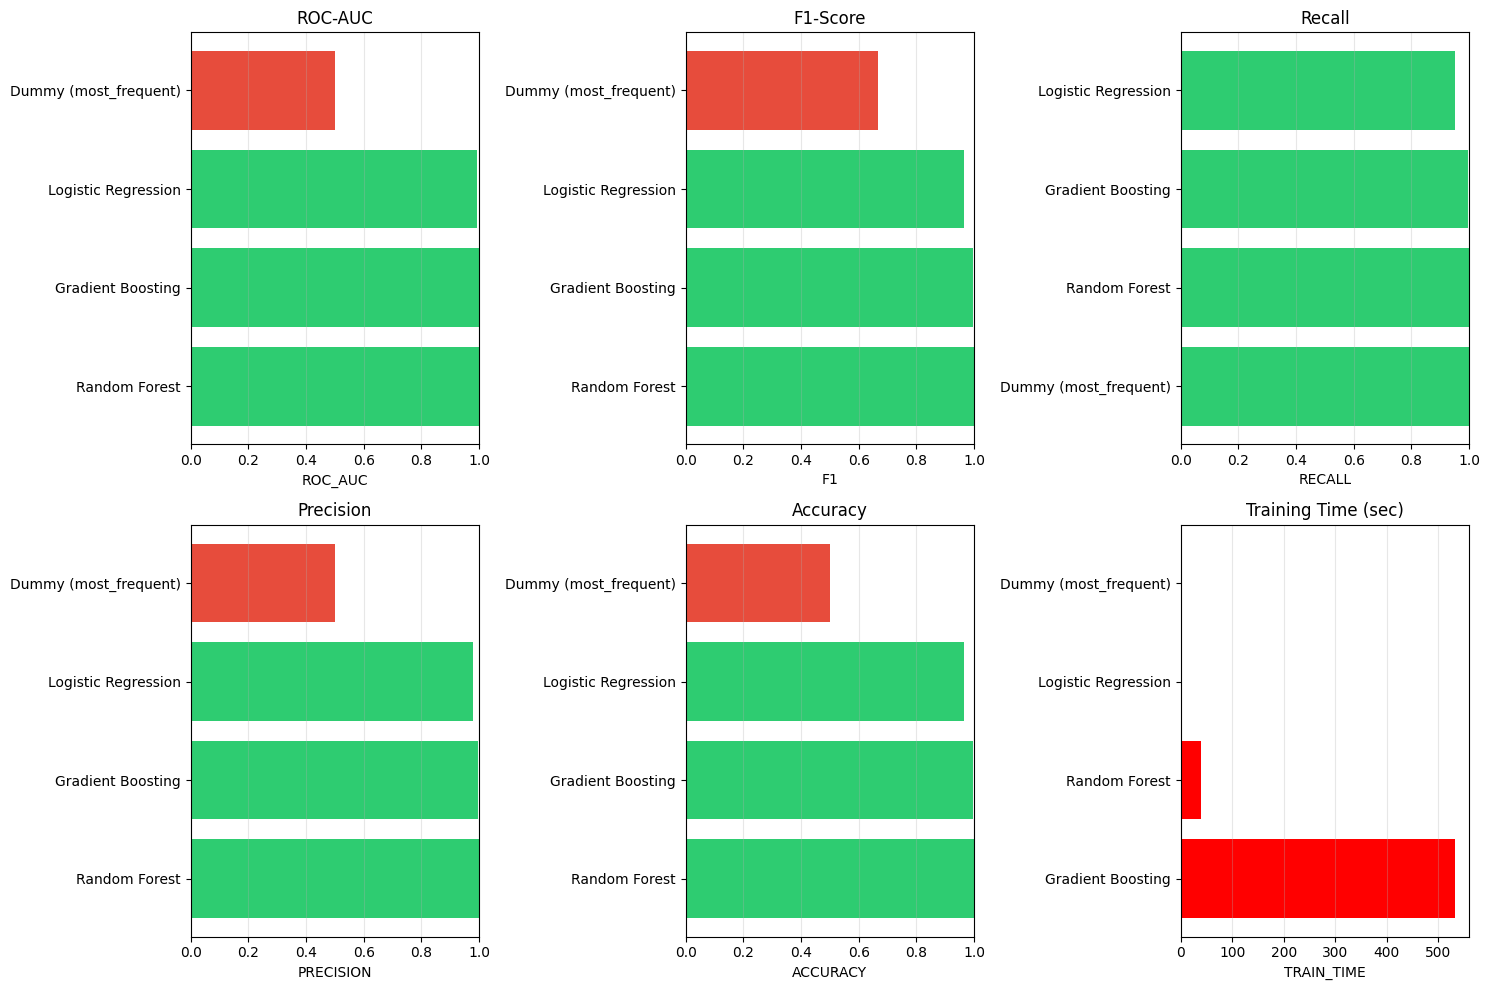

In [ ]:
# Визуализация сравнения
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics = ['roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'train_time']
titles = ['ROC-AUC', 'F1-Score', 'Recall', 'Precision', 'Accuracy', 'Training Time (sec)']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i//3, i%3]
    comparison_sorted = comparison.sort_values(metric, ascending=False)
    
    if metric == 'train_time':

        colors = ['red' if x > comparison['train_time'].median() else 'green' 
                  for x in comparison_sorted[metric]]
        ax.barh(comparison_sorted['name'], comparison_sorted[metric], color=colors)
        ax.set_xlabel(metric.upper())
    else:
        colors = ['#2ecc71' if x > 0.95 else '#e74c3c' for x in comparison_sorted[metric]]
        ax.barh(comparison_sorted['name'], comparison_sorted[metric], color=colors)
        ax.set_xlim(0, 1)
        ax.set_xlabel(metric.upper())
    
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [55]:
real_models = [r for r in results if r['name'] != 'Dummy (most_frequent)']
best_result = max(real_models, key=lambda x: x['roc_auc'])
best_model = best_result['model']
best_name = best_result['name']

print("\n" + "="*30)
print(f"BEST MODEL: {best_name}")
print("="*30)
print(f"Validation ROC-AUC: {best_result['roc_auc']:.6f}")
print(f"Validation F1:      {best_result['f1']:.6f}")
print(f"Validation Recall:  {best_result['recall']:.6f}")


BEST MODEL: Random Forest
Validation ROC-AUC: 0.999999
Validation F1:      0.999766
Validation Recall:  0.999977


In [56]:
# Предсказания на тесте
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Метрики на тесте
test_roc = roc_auc_score(y_test, y_test_pred_proba)
test_f1 = f1_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"ROC-AUC:        {test_roc:.6f}")
print(f"Accuracy:       {test_accuracy:.6f}")
print(f"Precision:      {test_precision:.6f}")
print(f"Recall:         {test_recall:.6f}")
print(f"F1-Score:       {test_f1:.6f}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Legit (0)", "Fraud (1)"]))

ROC-AUC:        0.999982
Accuracy:       0.999719
Precision:      0.999438
Recall:         1.000000
F1-Score:       0.999719

Classification Report:
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     42648
   Fraud (1)       1.00      1.00      1.00     42647

    accuracy                           1.00     85295
   macro avg       1.00      1.00      1.00     85295
weighted avg       1.00      1.00      1.00     85295



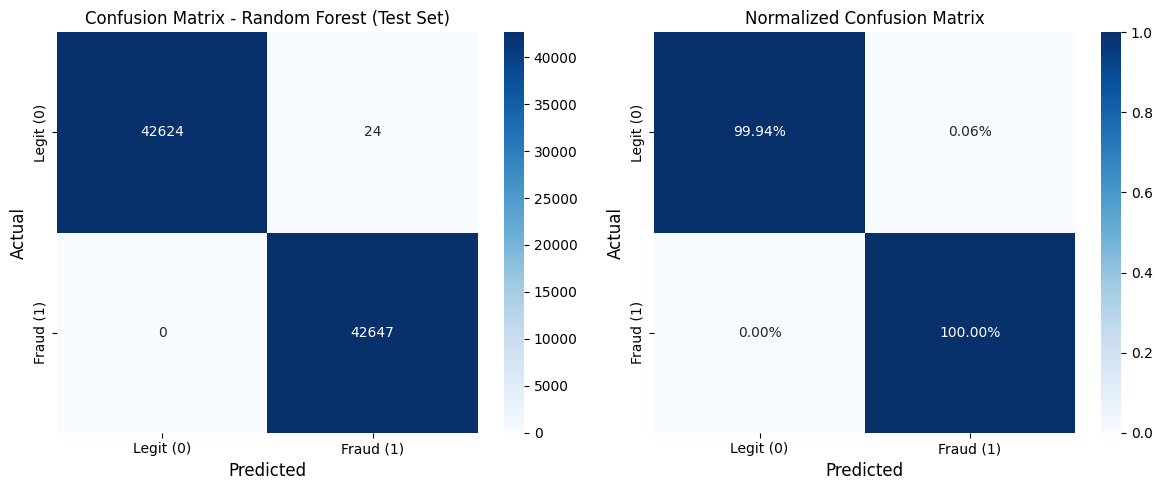

In [57]:
# Confusion Matrix визуализация
cm_test = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Heatmap
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legit (0)', 'Fraud (1)'], 
            yticklabels=['Legit (0)', 'Fraud (1)'],
            ax=axes[0])
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title(f'Confusion Matrix - {best_name} (Test Set)', fontsize=12)

# Нормализованная confusion matrix
cm_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Legit (0)', 'Fraud (1)'], 
            yticklabels=['Legit (0)', 'Fraud (1)'],
            ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Normalized Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

In [58]:
print("\n" + "="*30)
print("CONCLUSIONS")
print("="*30)

print(f"""
1. ЛУЧШАЯ BASELINE МОДЕЛЬ: {best_name}
   - ROC-AUC на тесте: {test_roc:.4f}
   - F1-Score: {test_f1:.4f}
   - Время обучения: {best_result['train_time']:.2f} сек

2. СРАВНЕНИЕ С DUMMY КЛАССИФИКАТОРОМ:
   - Dummy ROC-AUC: {dummy_results['roc_auc']:.4f}
   - Улучшение: {(test_roc - dummy_results['roc_auc'])*100:.2f}%

3. ВАЖНЫЕ НАБЛЮДЕНИЯ:
   - Модели показывают {"очень высокие" if test_roc > 0.99 else "хорошие"} результаты
""")


CONCLUSIONS

1. ЛУЧШАЯ BASELINE МОДЕЛЬ: Random Forest
   - ROC-AUC на тесте: 1.0000
   - F1-Score: 0.9997
   - Время обучения: 40.21 сек

2. СРАВНЕНИЕ С DUMMY КЛАССИФИКАТОРОМ:
   - Dummy ROC-AUC: 0.5000
   - Улучшение: 50.00%

3. ВАЖНЫЕ НАБЛЮДЕНИЯ:
   - Модели показывают очень высокие результаты

